In [1]:
!wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

--2025-06-07 17:25:02--  https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.1’

names.txt.1         100%[===================>] 222.80K  --.-KB/s    in 0.1s    

2025-06-07 17:25:03 (1.55 MB/s) - ‘names.txt.1’ saved [228145/228145]



In [4]:
with open('names.txt', 'r', encoding='UTF-8') as f:
    words = f.read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [5]:
min(len(w) for w in words)

2

In [6]:
max(len(w) for w in words)

15

In [5]:
# dictionary to track the statistics of how bigrams
# present themselves, i.e. how likely is a bigram to naturally occur
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        # b.get is useful here if bigram is not in the dictionary
        # and lets us default the value o
        b[bigram] = b.get(bigram, 0) + 1 

In [8]:
sorted_b = sorted(b.items(), reverse=True, key=lambda item: item[1])
sorted_b[:10]

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963)]

In [1]:
import torch

In [2]:
# Tensor for tracking the counts of each bigram
# where each row represents a character and each
# column is a the subsequent character in the bigram
N = torch.zeros((27, 27), dtype=torch.int32)

In [6]:
# Since we are now using an array to keep track of character counts
# we need to implement a lookup table for characters to integers
chars = ['.'] + sorted(list(set(''.join(words))))
# string to integer encoder 
stoi = {ch:i for i, ch in enumerate(chars)}
# Inverse mapping for the lookup table
itos = {i:ch for ch, i in stoi.items()}

In [7]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        N[idx1, idx2] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

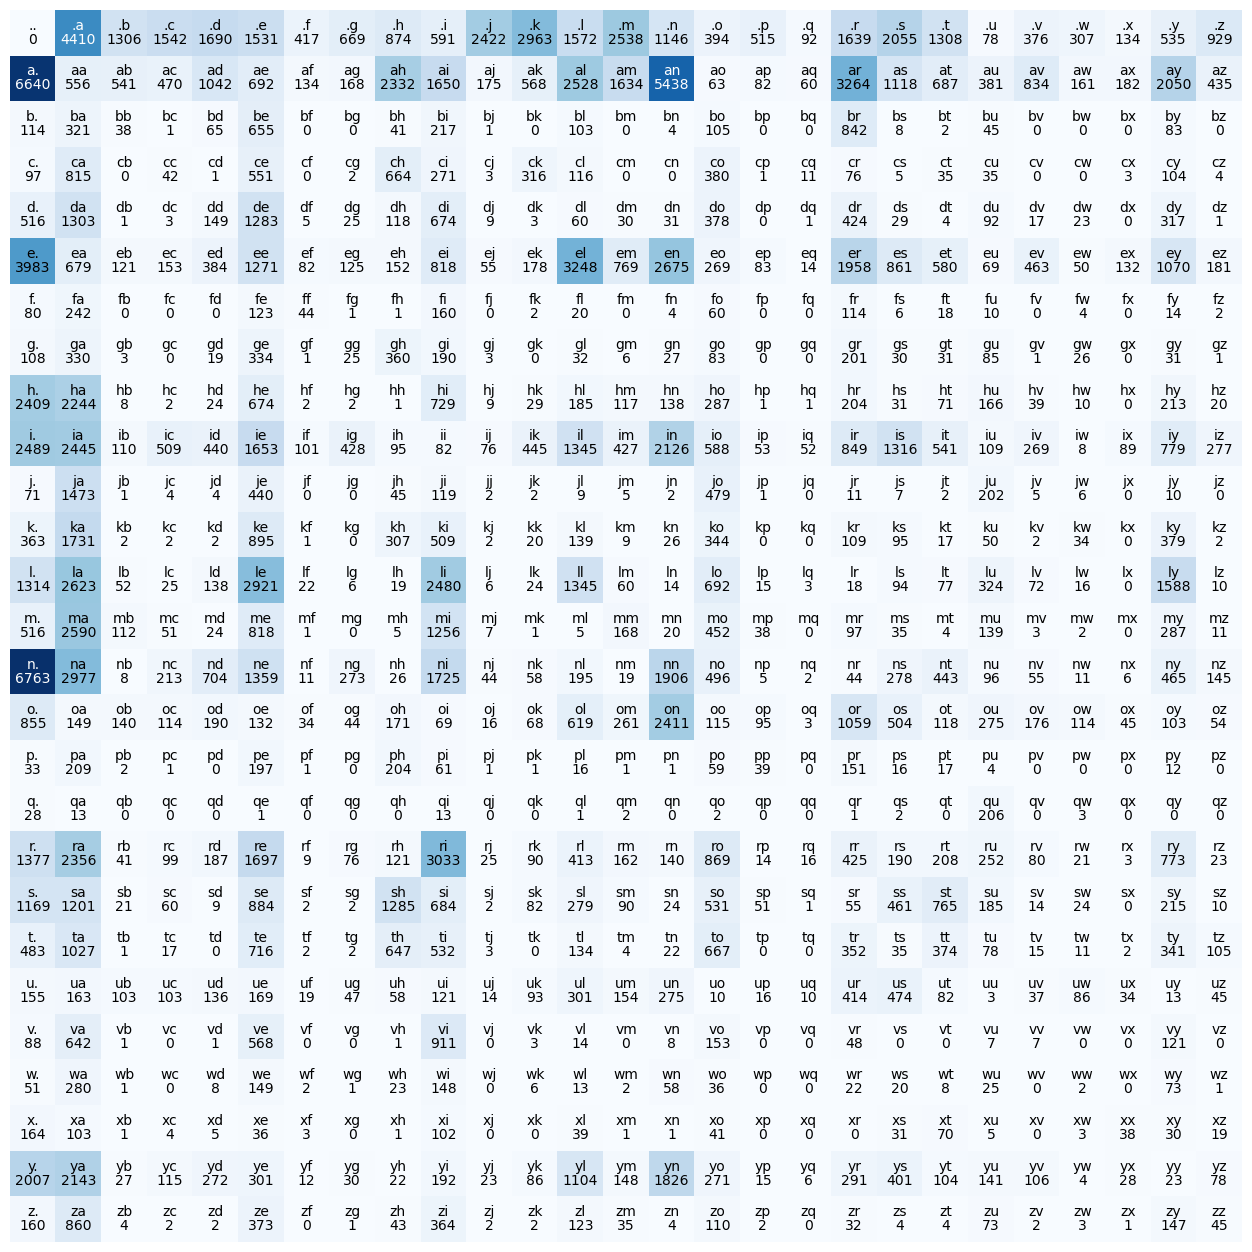

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Plotting the bigram counts as a matrix
plt.figure(figsize=(16, 16))
# As count increases, the luminance of a cell decreases, making
# one color of text difficult to read in all cases. To address this, 
# we can use a dynamic text color to use a dark color when cells are 
# lighter and vise versa
rgb_N = N / N.max()
cmap = plt.get_cmap('Blues')
plt.imshow(N, cmap=cmap)
for i in range(27):
    for j in range(27):
        bigram = itos[i] + itos[j]
        # extracting rbg values from each cell
        rgba = cmap(rgb_N[i, j].item())
        r, g, b = rgba[:3]
        # formula for perceived luminance from rgb values
        luminence = 0.299*r + 0.587*g + 0.114*b
        text_color = 'black' if luminence > 0.5 else 'white'
        plt.text(j, i, bigram, ha='center', va='bottom', color=text_color)
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color=text_color)
plt.axis('off')

In [ ]:
N[0].shape

torch.Size([27])

In [9]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [10]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [11]:
# Normalizing the counts of each row such that
# each row of P sums to 1 (Each row is a probability distribution)
# P - [27, 27] P.sum(...) - [27, 1] can it be broadcast?
# yes, the P.sum() [27, 1] is streched into a [27, 27] by copying the elements
# and then we preform an element-wise division
# https://docs.pytorch.org/docs/stable/notes/broadcasting.html

# N + 1 for model smoothing
P = (N+1).float()
# P = P / P.sum(axis=1, keepdim=True) creates new memory, instead use in place operation /=
P /= P.sum(axis=1, keepdim=True)

In [12]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20):
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        # p = torch.ones(27) / 27
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        # if we reach an end special character
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


In [ ]:
# We want to evaluate the model by seeing the likelihood the a particular name occurring
# which we can determine by taking the product of all the bigrams required to construct a name
# Ideally we would want for this likelihood to be close to 1, but since we are dealing with small
# numbers, the product of small numbers will be even smaller.
# Thus, we introduce the log likelihood, which monotonically transforms prob as such
# log(a*b*c) = log(a) + log(b) + log(c)

In [ ]:
# GOAL: Maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the neg log likelihood
# equivalent to minimizing the average neg log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [13]:
# Evaluating the model
log_likelihood = 0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        prob = P[idx1, idx2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f'{ch1}{ch2} with prob: {prob:.2f} {logprob:.2f}')
print(f'{log_likelihood=}')
# neg log likelihood is nice as a loss function because
# we like to minimize our loss, (small is good) by convention
nll = -log_likelihood
print(f'{nll=}')
# normalized log likelihood (average)
print(f'{nll/n:.3f}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.454


In [14]:
log_likelihood = 0
n = 0
# qq has a count of 0 in out bigram matrix
for w in ['zyanqq']:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        prob = P[idx1, idx2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f'{ch1}{ch2} with prob: {prob:.2f} {logprob:.2f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n:.3f}')

log_likelihood=tensor(-26.4393)
nll=tensor(26.4393)
3.777


In [ ]:
# We may not a like this model to provide inf loss for a name 
# just because we cannot represent from the counts in our training data.
# we can work around inf loss by "smoothing" our model by adding fake counts 
# across the counts matrix. 
# Adding small n -> more peaked model. 
# Adding large n -> more uniform model

In [15]:
# Train another model using a neural network

# Create the training set of bigrams (x, y)
xs, ys = [], []
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(idx1)
        ys.append(idx2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [ ]:
xs

tensor([ 0,  5, 13, 13,  1])

In [ ]:
ys

tensor([ 5, 13, 13,  1,  0])

In [16]:
import torch.nn.functional as F
# we want the dtype to be a float so values can take on 
# decimal values in the neural network. We can do this by
# casting the array with .float() method
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

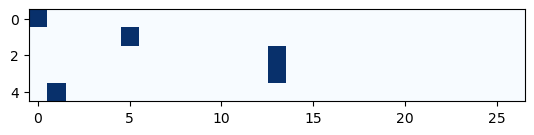

In [ ]:
plt.imshow(xenc, cmap='Blues')

In [ ]:
xenc.dtype

torch.float32

In [ ]:
# samples for standard normal distribution
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)
# @ is matrix mult operator in pytorch
xenc @ W

tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
         -2.9644e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01,
         -4.7125e-01,  7.8682e-01, -3.2844e-01, -4.3297e-01,  1.3729e+00,
          2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4040e-01,
          9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0731e-02,
          2.4968e+00,  2.4448e+00],
        [ 4.7236e-01,  1.4830e+00,  3.1748e-01,  1.0588e+00,  2.3982e+00,
          4.6827e-01, -6.5650e-01,  6.1662e-01, -6.2198e-01,  5.1007e-01,
          1.3563e+00,  2.3445e-01, -4.5585e-01, -1.3132e-03, -5.1161e-01,
          5.5570e-01,  4.7458e-01, -1.3867e+00,  1.6229e+00,  1.7197e-01,
          9.8846e-01,  5.0657e-01,  1.0198e+00, -1.9062e+00, -4.2753e-01,
         -2.1259e+00,  9.6041e-01],
        [ 1.9359e-01,  1.0532e+00,  6.3393e-01,  2.5786e-01,  9.6408e-01,
         -2.4855e-01,  2.4756e-02, -3.0404e-02,  1.5622e+00, -4.4852e-01,
         -1.2345e+00,  1.1220e+00, -6.73

In [ ]:
# since we sample from standard normal distribution, we have a mix of positive
# and negative numbers. We would like to have some kind of probability distribution
# as an output layer, and for that lets consider these outputs as log(counts). Then
# taking exp(log(counts)) -> counts, which we can then normalize to obtain a
# probability distribution
# Note: We are making this decision arbitrarily but it will have meaning with
# respect to the loss function while training. It is ultimately still useful
# because it shifts our range from (-inf, inf) -> (0, inf).

In [ ]:
# xenc - [5, 27] @ W - [27, 27] -> [5, 27]
# this is a dot product between each one hot vector 
# and the weights

In [18]:
logits = (xenc @ W) # log-counts
counts = logits.exp() # equivalent to N Matrix
probs = counts / counts.sum(axis=1, keepdims=True)
# last two lines are a softmax
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [19]:
probs.shape

torch.Size([5, 27])

In [20]:
# going through each bigram in the name .emma.
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item()
    y = ys[i].item()

    print('------')
    print(f'Example {i+1}: {itos[x]}{itos[y]} (indexes {x}, {y})')
    print('input to neural net:', x, F.one_hot(torch.tensor(x), num_classes=27))
    print('output probabilities from neural net:', probs[i])
    print(f'label: {y}')
    p = probs[i, y]
    logp = torch.log(p)
    nll = -logp
    nlls[i] = nll
    print(f'Probability assigned by neural network: {p.item():.4f}')
    print(f'Log Likelihood: {logp.item():.2f}')
    print(f'Neg Log Likelihood: {nll.item():.2f}')

print('--------')
print(f'Average Neg Log Likelihood: {nlls.mean().item()}')

------
Example 1: .e (indexes 0, 5)
input to neural net: 0 tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])
output probabilities from neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label: 5
Probability assigned by neural network: 0.0123
Log Likelihood: -4.40
Neg Log Likelihood: 4.40
------
Example 2: em (indexes 5, 13)
input to neural net: 5 tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])
output probabilities from neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label: 13
Probability as

In [ ]:
# randomly initialize 27 neurons
g = torch.Generator().manual_seed(2147483647)
# enabling requires_grad creates a compute graph of all differentiable
# transformations applied to the weights which can be used to back-propagate
# through the network
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [40]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = (xenc @ W) # log-counts
counts = logits.exp() # equivalent to N Matrix
probs = counts / counts.sum(axis=1, keepdims=True)
loss = -probs[torch.arange(5), ys].log().mean()

In [41]:
print(loss.item())

3.7291626930236816


In [38]:
# backward pass
W.grad = None # set gradient to 0, more efficient to use None
loss.backward()

In [33]:
print(W.shape)
print(W.grad.shape)

torch.Size([27, 27])
torch.Size([27, 27])


In [39]:
# nudge our weights in the opposite direction of the 
# gradient to converge toward a local minimum for the loss function
W.data += -0.1 * W.grad